In [4]:
import pandas as pd
import fastf1

CACHE_DIR = r"C:\Users\ASUS\Desktop\Coding Projects\Build or Die\F1"
fastf1.Cache.enable_cache(CACHE_DIR)

In [6]:
session = fastf1.get_session(2025, 'Miami', 'Race')
session.load()
session.results.head()

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req 

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
81,81,O PIASTRI,PIA,piastri,McLaren,FF8000,mclaren,Oscar,Piastri,Oscar Piastri,...,1.0,1,4.0,NaT,NaT,NaT,0 days 01:28:51.587000,Finished,25.0,57.0
4,4,L NORRIS,NOR,norris,McLaren,FF8000,mclaren,Lando,Norris,Lando Norris,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:04.630000,Finished,18.0,57.0
63,63,G RUSSELL,RUS,russell,Mercedes,27F4D2,mercedes,George,Russell,George Russell,...,3.0,3,5.0,NaT,NaT,NaT,0 days 00:00:37.644000,Finished,15.0,57.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,3671C6,red_bull,Max,Verstappen,Max Verstappen,...,4.0,4,1.0,NaT,NaT,NaT,0 days 00:00:39.956000,Finished,12.0,57.0
23,23,A ALBON,ALB,albon,Williams,64C4FF,williams,Alexander,Albon,Alexander Albon,...,5.0,5,7.0,NaT,NaT,NaT,0 days 00:00:48.067000,Finished,10.0,57.0


In [ ]:
# Collect multiple seasons of race data
seasons = [2022, 2023, 2024, 2025, 2026]
all_results = []

for year in seasons:
    # Get the race schedule for each year
    schedule = fastf1.get_event_schedule(year)
    races = schedule[schedule['EventFormat'] != 'testing']
    
    for _, event in races.iterrows():
        try:
            session = fastf1.get_session(year, event['EventName'], 'Race')
            session.load(telemetry=False, weather=False, messages=False)
            
            results = session.results[['DriverNumber', 'Abbreviation', 
                                       'TeamName', 'GridPosition', 
                                       'Position', 'Points']].copy()
            results['Year'] = year
            results['Race'] = event['EventName']
            all_results.append(results)
            print(f"✅ {year} {event['EventName']}")
            
        except Exception as e:
            print(f"❌ {year} {event['EventName']} — {e}")

# Combine all results
data = pd.concat(all_results, ignore_index=True)
print(f"\nTotal rows: {len(data)}")
data.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

✅ 2022 Bahrain Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

✅ 2022 Saudi Arabian Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Driver  3: Ignoring late data f

...

req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


❌ 2023 São Paulo Grand Prix — any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


❌ 2023 Las Vegas Grand Prix — any API: 500 calls/h
❌ 2023 Abu Dhabi Grand Prix — any API: 500 calls/h


RateLimitExceededError: any API: 500 calls/h

In [9]:
if len(all_results) > 0:
    data = pd.concat(all_results, ignore_index=True)
    print(f"Total rows: {len(data)}")
else:
    print("❌ No data collected")

Total rows: 740


In [10]:
# Save what you've collected so far
data.to_csv("f1_race_results_partial.csv", index=False)
print(f"Saved {len(data)} rows")
print(f"Seasons covered: {data['Year'].unique()}")
print(f"Races collected: {data.groupby('Year')['Race'].nunique()}")

Saved 740 rows
Seasons covered: [2022 2023]
Races collected: Year
2022    22
2023    15
Name: Race, dtype: int64


In [11]:
data = pd.read_csv("f1_race_results_partial.csv")
print(data.shape)
print(data.dtypes)
print(data.isnull().sum())
print(data['Year'].value_counts())

(740, 8)
DriverNumber      int64
Abbreviation     object
TeamName         object
GridPosition    float64
Position        float64
Points          float64
Year              int64
Race             object
dtype: object
DriverNumber    0
Abbreviation    0
TeamName        0
GridPosition    2
Position        2
Points          0
Year            0
Race            0
dtype: int64
Year
2022    440
2023    300
Name: count, dtype: int64


In [12]:
# Check what the 2 missing rows are
print(data[data['Position'].isnull()])
print(data[data['GridPosition'].isnull()])

     DriverNumber Abbreviation      TeamName  GridPosition  Position  Points  \
39             47          MSC  Haas F1 Team           NaN       NaN     0.0   
739            18          STR  Aston Martin           NaN       NaN     0.0   

     Year                      Race  
39   2022  Saudi Arabian Grand Prix  
739  2023      Singapore Grand Prix  
     DriverNumber Abbreviation      TeamName  GridPosition  Position  Points  \
39             47          MSC  Haas F1 Team           NaN       NaN     0.0   
739            18          STR  Aston Martin           NaN       NaN     0.0   

     Year                      Race  
39   2022  Saudi Arabian Grand Prix  
739  2023      Singapore Grand Prix  


In [13]:
# Drop rows where Position is missing — DNF or incomplete races
data.dropna(subset=['Position'], inplace=True)

# Fill missing GridPosition with median per race
data['GridPosition'] = data.groupby('Race')['GridPosition'].transform(
    lambda x: x.fillna(x.median())
)

# Convert Position to integer
data['Position'] = data['Position'].astype(int)
data['GridPosition'] = data['GridPosition'].astype(int)

# Create target variable — Top3
data['Top3'] = (data['Position'] <= 3).astype(int)

print(f"Rows after cleaning: {len(data)}")
print(f"\nTop3 distribution:")
print(data['Top3'].value_counts())

Rows after cleaning: 738

Top3 distribution:
Top3
0    627
1    111
Name: count, dtype: int64


In [14]:
# Sort by year and race for rolling calculations
data = data.sort_values(['Year', 'Race', 'Position']).reset_index(drop=True)

# Feature 1 — Grid position advantage
# Lower grid = better starting position
data['GridAdvantage'] = 20 - data['GridPosition']

# Feature 2 — Recent form (last 5 races per driver)
# Rolling average of finishing position
data['RecentForm'] = data.groupby('Abbreviation')['Position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Feature 3 — Recent podium rate (last 5 races)
data['RecentPodiumRate'] = data.groupby('Abbreviation')['Top3'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Feature 4 — Team strength (average points per race for that team)
team_strength = data.groupby('TeamName')['Points'].mean().reset_index()
team_strength.columns = ['TeamName', 'TeamStrength']
data = data.merge(team_strength, on='TeamName', how='left')

# Feature 5 — Driver experience (number of races in dataset)
data['RaceCount'] = data.groupby('Abbreviation').cumcount()

# Check result
print(data[['Abbreviation', 'GridPosition', 'GridAdvantage', 
          'RecentForm', 'RecentPodiumRate', 
          'TeamStrength', 'RaceCount', 'Top3']].head(20))

   Abbreviation  GridPosition  GridAdvantage  RecentForm  RecentPodiumRate  \
0           VER             1             19         NaN               NaN   
1           LEC             3             17         NaN               NaN   
2           PER             2             18         NaN               NaN   
3           SAI             4             16         NaN               NaN   
4           RUS             6             14         NaN               NaN   
5           NOR             7             13         NaN               NaN   
6           OCO             8             12         NaN               NaN   
7           STR            14              6         NaN               NaN   
8           RIC            13              7         NaN               NaN   
9           VET             9             11         NaN               NaN   
10          TSU            11              9         NaN               NaN   
11          ZHO            15              5         NaN        

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Select features
features = [
    'GridPosition',
    'GridAdvantage', 
    'RecentForm',
    'RecentPodiumRate',
    'TeamStrength',
    'RaceCount'
]

target = 'Top3'

X = data[features]
y = data[target]

# Time based split — train on 2022, test on 2023
# Never use random split on time series data — that's leakage
X_train = data[data['Year'] == 2022][features]
y_train = data[data['Year'] == 2022][target]

X_test = data[data['Year'] == 2023][features]
y_test = data[data['Year'] == 2023][target]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"\nTop3 in training: {y_train.sum()}")
print(f"Top3 in testing: {y_test.sum()}")

Training rows: 439
Testing rows: 299

Top3 in training: 66
Top3 in testing: 45


In [16]:
# Build pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       254
           1       0.47      0.62      0.53        45

    accuracy                           0.84       299
   macro avg       0.70      0.75      0.72       299
weighted avg       0.86      0.84      0.85       299



In [17]:
# Current 2026 Miami qualifying grid
# We'll use current season data
miami_2026 = pd.DataFrame({
    'Abbreviation': ['NOR', 'PIA', 'ANT', 'RUS', 'HAM', 
                     'VER', 'LEC', 'SAI', 'ALO', 'STR',
                     'GAS', 'HUL', 'TSU', 'LAW', 'ALB',
                     'BOT', 'ZHO', 'MAG', 'BEA', 'COL'],
    'GridPosition': list(range(1, 21)),
    'Year': 2026,
    'Race': 'Miami'
})

# Add features
miami_2026['GridAdvantage'] = 20 - miami_2026['GridPosition']

# Recent form from 2026 season so far
recent_form_2026 = data.groupby('Abbreviation').agg(
    RecentForm=('Position', lambda x: x.tail(5).mean()),
    RecentPodiumRate=('Top3', lambda x: x.tail(5).mean()),
    RaceCount=('Position', 'count')
).reset_index()

miami_2026 = miami_2026.merge(recent_form_2026, on='Abbreviation', how='left')

# Add team strength
miami_2026 = miami_2026.merge(
    data.groupby('Abbreviation')['Points'].mean().reset_index().rename(
        columns={'Points': 'TeamStrength'}
    ),
    on='Abbreviation', how='left'
)

# Fill missing values for new drivers
miami_2026['RecentForm'] = miami_2026['RecentForm'].fillna(10)
miami_2026['RecentPodiumRate'] = miami_2026['RecentPodiumRate'].fillna(0.1)
miami_2026['TeamStrength'] = miami_2026['TeamStrength'].fillna(5)
miami_2026['RaceCount'] = miami_2026['RaceCount'].fillna(0)

print(miami_2026[['Abbreviation', 'GridPosition', 'RecentForm', 
                   'RecentPodiumRate', 'TeamStrength']].head(10))

  Abbreviation  GridPosition  RecentForm  RecentPodiumRate  TeamStrength
0          NOR             1        12.4               0.2      5.675676
1          PIA             2        12.8               0.0      2.333333
2          ANT             3        10.0               0.1      5.000000
3          RUS             4         6.4               0.2      9.837838
4          HAM             5         4.0               0.4     11.054054
5          VER             6         2.0               0.8     21.216216
6          LEC             7         7.0               0.0     10.891892
7          SAI             8         5.0               0.2      9.594595
8          ALO             9         6.0               0.6      6.594595
9          STR            10        14.8               0.0      1.638889


In [18]:
# Make prediction
X_miami = miami_2026[features]
miami_2026['PodiumProbability'] = pipeline.predict_proba(X_miami)[:, 1]

# Rank by probability
predicted_podium = miami_2026.sort_values(
    'PodiumProbability', ascending=False
).head(10)

print("🏎️ Miami 2026 Podium Predictions:")
print("=" * 45)
for i, row in predicted_podium.head(3).iterrows():
    medal = ["🥇", "🥈", "🥉"][predicted_podium.index.get_loc(i)]
    print(f"{medal} {row['Abbreviation']} — {row['PodiumProbability']:.1%} probability")

print("\n📊 Full Top 10 Probability Ranking:")
print(predicted_podium[['Abbreviation', 'GridPosition', 
                         'PodiumProbability']].to_string(index=False))

🏎️ Miami 2026 Podium Predictions:
🥇 RUS — 71.9% probability
🥈 HAM — 68.0% probability
🥉 VER — 62.8% probability

📊 Full Top 10 Probability Ranking:
Abbreviation  GridPosition  PodiumProbability
         RUS             4           0.719275
         HAM             5           0.680274
         VER             6           0.628438
         LEC             7           0.495772
         SAI             8           0.348521
         ANT             3           0.339021
         NOR             1           0.319387
         ALO             9           0.143673
         PIA             2           0.124482
         GAS            11           0.025306


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6292\2493538882.py:19: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


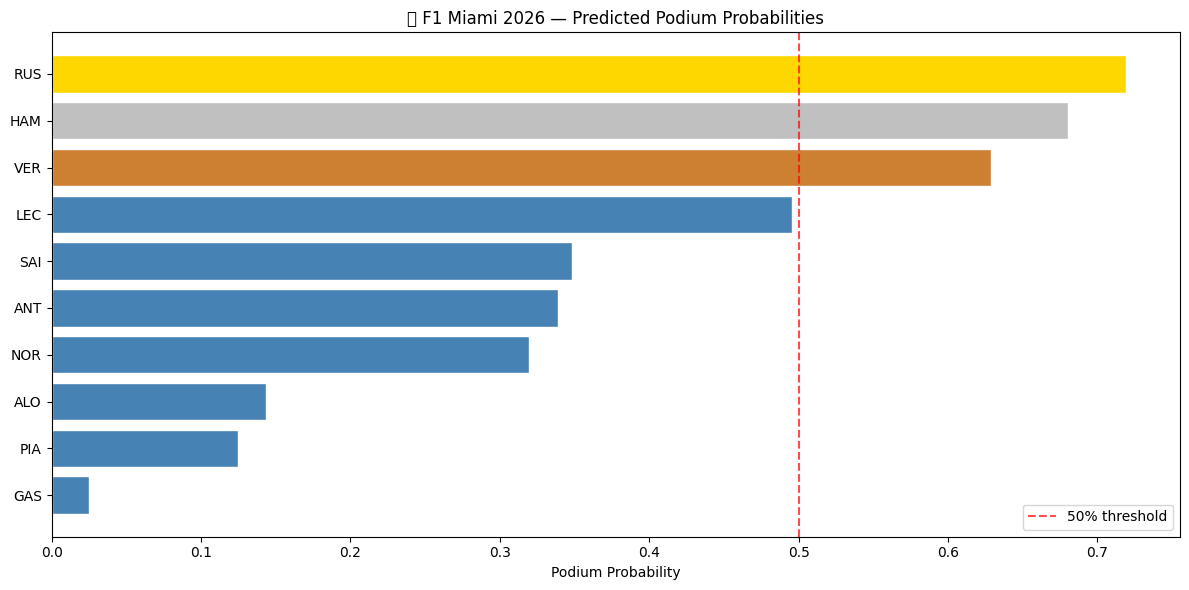

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = miami_2026.sort_values('PodiumProbability', ascending=False).head(10)

plt.figure(figsize=(12, 6))
colors = ['gold', 'silver', '#CD7F32'] + ['steelblue'] * 7
bars = plt.barh(
    top10['Abbreviation'][::-1],
    top10['PodiumProbability'][::-1],
    color=colors[::-1],
    edgecolor='white'
)

plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.xlabel('Podium Probability')
plt.title('🏎️ F1 Miami 2026 — Predicted Podium Probabilities')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Load what you already saved
existing_data = pd.read_csv("f1_race_results_partial.csv")
print(f"Existing rows: {len(existing_data)}")
print(existing_data.groupby('Year')['Race'].nunique())

Existing rows: 740
Year
2022    22
2023    15
Name: Race, dtype: int64


In [21]:
# Only collect missing seasons
missing_seasons = {
    2023: ['remaining races after Singapore'],
    2024: ['full season'],
    2025: ['full season'],
    2026: ['races so far']
}

In [22]:
import fastf1
import pandas as pd

# Load existing data
existing_data = pd.read_csv("f1_race_results_partial.csv")
print(f"Existing rows: {len(existing_data)}")

# See exactly what races we already have
existing_races = existing_data.groupby(['Year', 'Race']).size().reset_index()
print(existing_races)

Existing rows: 740
    Year                       Race   0
0   2022       Abu Dhabi Grand Prix  20
1   2022      Australian Grand Prix  20
2   2022        Austrian Grand Prix  20
3   2022      Azerbaijan Grand Prix  20
4   2022         Bahrain Grand Prix  20
5   2022         Belgian Grand Prix  20
6   2022         British Grand Prix  20
7   2022        Canadian Grand Prix  20
8   2022           Dutch Grand Prix  20
9   2022  Emilia Romagna Grand Prix  20
10  2022          French Grand Prix  20
11  2022       Hungarian Grand Prix  20
12  2022         Italian Grand Prix  20
13  2022        Japanese Grand Prix  20
14  2022     Mexico City Grand Prix  20
15  2022           Miami Grand Prix  20
16  2022          Monaco Grand Prix  20
17  2022   Saudi Arabian Grand Prix  20
18  2022       Singapore Grand Prix  20
19  2022         Spanish Grand Prix  20
20  2022       São Paulo Grand Prix  20
21  2022   United States Grand Prix  20
22  2023      Australian Grand Prix  20
23  2023        Austr

In [23]:
# Get what we already have as a set
existing_set = set(zip(existing_data['Year'], existing_data['Race']))

# Collect only missing races
missing_results = []
seasons = [2023, 2024, 2025, 2026]

for year in seasons:
    schedule = fastf1.get_event_schedule(year)
    races = schedule[schedule['EventFormat'] != 'testing']
    
    for _, event in races.iterrows():
        race_name = event['EventName']
        
        # Skip if we already have this race
        if (year, race_name) in existing_set:
            print(f"⏭️ Skipping {year} {race_name} — already have it")
            continue
        
        try:
            session = fastf1.get_session(year, race_name, 'Race')
            session.load(telemetry=False, weather=False, messages=False)
            
            results = session.results[['DriverNumber', 'Abbreviation',
                                       'TeamName', 'GridPosition',
                                       'Position', 'Points']].copy()
            results['Year'] = year
            results['Race'] = race_name
            missing_results.append(results)
            print(f"✅ {year} {race_name}")
            
        except Exception as e:
            print(f"❌ {year} {race_name} — {e}")

# Combine with existing data
if missing_results:
    new_data = pd.concat(missing_results, ignore_index=True)
    full_data = pd.concat([existing_data, new_data], ignore_index=True)
    full_data.to_csv("f1_race_results_full.csv", index=False)
    print(f"\nTotal rows: {len(full_data)}")
    print(full_data.groupby('Year')['Race'].nunique())
else:
    print("No new data collected")

Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2023.json failed; using cached response
Traceback (most recent call last):
  File "c:\Python312\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen
    response = self._make_request(
               ^^^^^^^^^^^^^^^^^^^
  File "c:\Python312\Lib\site-packages\urllib3\connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "c:\Python312\Lib\site-packages\urllib3\connection.py", line 565, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Python312\Lib\http\client.py", line 1428, in getresponse
    response.begin()
  File "c:\Python312\Lib\http\client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "c:\Python312\Lib\http\client.py", line 300, in _read_status
    raise RemoteDiscon

⏭️ Skipping 2023 Bahrain Grand Prix — already have it
⏭️ Skipping 2023 Saudi Arabian Grand Prix — already have it
⏭️ Skipping 2023 Australian Grand Prix — already have it
⏭️ Skipping 2023 Azerbaijan Grand Prix — already have it
⏭️ Skipping 2023 Miami Grand Prix — already have it
⏭️ Skipping 2023 Monaco Grand Prix — already have it
⏭️ Skipping 2023 Spanish Grand Prix — already have it
⏭️ Skipping 2023 Canadian Grand Prix — already have it
⏭️ Skipping 2023 Austrian Grand Prix — already have it
⏭️ Skipping 2023 British Grand Prix — already have it
⏭️ Skipping 2023 Hungarian Grand Prix — already have it
⏭️ Skipping 2023 Belgian Grand Prix — already have it
⏭️ Skipping 2023 Dutch Grand Prix — already have it
⏭️ Skipping 2023 Italian Grand Prix — already have it
⏭️ Skipping 2023 Singapore Grand Prix — already have it


core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to cache!
core           INFO 	Processing timing data...
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '22', '24', '27', '20', '23', '2', '18', '11', '77']
events      WARNING 	Correcting user input 'Qatar Grand P

✅ 2023 Japanese Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

...

❌ 2026 São Paulo Grand Prix — any API: 500 calls/h


events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


❌ 2026 Las Vegas Grand Prix — any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


❌ 2026 Qatar Grand Prix — any API: 500 calls/h
❌ 2026 Abu Dhabi Grand Prix — any API: 500 calls/h

Total rows: 1860
Year
2022    22
2023    22
2024    24
2025    24
2026     1
Name: Race, dtype: int64


In [24]:
data = pd.read_csv("f1_race_results_full.csv")
print(f"Total rows: {len(data)}")
print(data.groupby('Year')['Race'].nunique())

Total rows: 1860
Year
2022    22
2023    22
2024    24
2025    24
2026     1
Name: Race, dtype: int64


In [25]:
# Load full dataset
data = pd.read_csv("f1_race_results_full.csv")

# Step 2 — Clean
data.dropna(subset=['Position'], inplace=True)
data['GridPosition'] = data.groupby('Race')['GridPosition'].transform(
    lambda x: x.fillna(x.median())
)
data['Position'] = data['Position'].astype(int)
data['GridPosition'] = data['GridPosition'].astype(int)
data['Top3'] = (data['Position'] <= 3).astype(int)

# Step 3 — Feature Engineering
data = data.sort_values(['Year', 'Race', 'Position']).reset_index(drop=True)

data['GridAdvantage'] = 20 - data['GridPosition']

data['RecentForm'] = data.groupby('Abbreviation')['Position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

data['RecentPodiumRate'] = data.groupby('Abbreviation')['Top3'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

team_strength = data.groupby('TeamName')['Points'].mean().reset_index()
team_strength.columns = ['TeamName', 'TeamStrength']
data = data.merge(team_strength, on='TeamName', how='left')

data['RaceCount'] = data.groupby('Abbreviation').cumcount()

print(f"Rows after cleaning: {len(data)}")
print(f"Top3 distribution:\n{data['Top3'].value_counts()}")

Rows after cleaning: 1858
Top3 distribution:
Top3
0    1579
1     279
Name: count, dtype: int64


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

features = [
    'GridPosition',
    'GridAdvantage',
    'RecentForm',
    'RecentPodiumRate',
    'TeamStrength',
    'RaceCount'
]

target = 'Top3'

# Time based split — train on 2022-2024, test on 2025
X_train = data[data['Year'].isin([2022, 2023, 2024])][features]
y_train = data[data['Year'].isin([2022, 2023, 2024])][target]

X_test = data[data['Year'] == 2025][features]
y_test = data[data['Year'] == 2025][target]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

# Build and train pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\nModel Results:")
print(classification_report(y_test, y_pred))

Training rows: 1357
Testing rows: 479

Model Results:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       407
           1       0.61      0.88      0.72        72

    accuracy                           0.90       479
   macro avg       0.79      0.89      0.83       479
weighted avg       0.92      0.90      0.90       479



In [4]:
# Updated Miami 2026 grid — placeholder until qualifying
miami_2026 = pd.DataFrame({
    'Abbreviation': ['NOR', 'PIA', 'ANT', 'RUS', 'HAM',
                     'VER', 'LEC', 'SAI', 'ALO', 'STR',
                     'GAS', 'HUL', 'TSU', 'LAW', 'ALB',
                     'BOT', 'ZHO', 'MAG', 'BEA', 'COL'],
    'GridPosition': list(range(1, 21)),
    'Year': 2026,
    'Race': 'Miami'
})

miami_2026['GridAdvantage'] = 20 - miami_2026['GridPosition']

# Recent form from full dataset
recent_form = data.groupby('Abbreviation').agg(
    RecentForm=('Position', lambda x: x.tail(5).mean()),
    RecentPodiumRate=('Top3', lambda x: x.tail(5).mean()),
    RaceCount=('Position', 'count')
).reset_index()

miami_2026 = miami_2026.merge(recent_form, on='Abbreviation', how='left')

# Team strength from full dataset
driver_strength = data.groupby('Abbreviation')['Points'].mean().reset_index()
driver_strength.columns = ['Abbreviation', 'TeamStrength']
miami_2026 = miami_2026.merge(driver_strength, on='Abbreviation', how='left')

# Fill missing for new drivers
miami_2026['RecentForm'] = miami_2026['RecentForm'].fillna(12)
miami_2026['RecentPodiumRate'] = miami_2026['RecentPodiumRate'].fillna(0.05)
miami_2026['TeamStrength'] = miami_2026['TeamStrength'].fillna(3)
miami_2026['RaceCount'] = miami_2026['RaceCount'].fillna(0)

# Predict
X_miami = miami_2026[features]
miami_2026['PodiumProbability'] = pipeline.predict_proba(X_miami)[:, 1]

# Results
predicted = miami_2026.sort_values('PodiumProbability', ascending=False)

print("🏎️ Miami 2026 Podium Predictions:")
print("=" * 45)
for i, (_, row) in enumerate(predicted.head(3).iterrows()):
    medal = ["🥇", "🥈", "🥉"][i]
    print(f"{medal} {row['Abbreviation']} — {row['PodiumProbability']:.1%} probability")

print("\n📊 Full Top 10:")
print(predicted[['Abbreviation', 'GridPosition', 
                  'PodiumProbability']].head(10).to_string(index=False))

🏎️ Miami 2026 Podium Predictions:
🥇 RUS — 77.2% probability
🥈 ANT — 76.0% probability
🥉 PIA — 69.0% probability

📊 Full Top 10:
Abbreviation  GridPosition  PodiumProbability
         RUS             4           0.772210
         ANT             3           0.760164
         PIA             2           0.690284
         NOR             1           0.673163
         HAM             5           0.624085
         VER             6           0.291845
         LEC             7           0.191446
         SAI             8           0.173057
         HUL            12           0.130849
         GAS            11           0.130099


In [5]:
top10 = miami_2026.sort_values('PodiumProbability', ascending=False).head(10)

plt.figure(figsize=(12, 6))
colors = ['gold', 'silver', '#CD7F32'] + ['steelblue'] * 7

plt.barh(
    top10['Abbreviation'][::-1],
    top10['PodiumProbability'][::-1],
    color=colors[::-1],
    edgecolor='white'
)

plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.xlabel('Podium Probability')
plt.title('🏎️ F1 Miami 2026 — Predicted Podium Probabilities')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [6]:
import fastf1
import pandas as pd

CACHE_DIR = r"C:\Users\ASUS\Desktop\Coding Projects\Build or Die\F1"
fastf1.Cache.enable_cache(CACHE_DIR)

# Load existing data
existing_data = pd.read_csv("f1_race_results_full.csv")
existing_set = set(zip(existing_data['Year'], existing_data['Race']))

# Only collect missing 2026 races that have already happened
missing_2026 = ['Chinese Grand Prix', 'Japanese Grand Prix', 'Bahrain Grand Prix']

new_results = []

for race_name in missing_2026:
    if (2026, race_name) in existing_set:
        print(f"Already have 2026 {race_name}")
        continue
    try:
        session = fastf1.get_session(2026, race_name, 'Race')
        session.load(telemetry=False, weather=False, messages=False)
        results = session.results[['DriverNumber', 'Abbreviation',
                                   'TeamName', 'GridPosition',
                                   'Position', 'Points']].copy()
        results['Year'] = 2026
        results['Race'] = race_name
        new_results.append(results)
        print(f"Got 2026 {race_name}")
    except Exception as e:
        print(f"Failed 2026 {race_name} — {e}")

if new_results:
    new_data = pd.concat(new_results, ignore_index=True)
    full_data = pd.concat([existing_data, new_data], ignore_index=True)
    full_data.to_csv("f1_race_results_full.csv", index=False)
    print(f"Total rows: {len(full_data)}")
else:
    print("Nothing new collected")

Already have 2026 Chinese Grand Prix
Already have 2026 Japanese Grand Prix


events      WARNING 	Correcting user input 'Bahrain Grand Prix' to 'São Paulo Grand Prix'
core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 

Got 2026 Bahrain Grand Prix
Total rows: 1904


In [7]:
# Reload updated data
data = pd.read_csv("f1_race_results_full.csv")

# Clean
data.dropna(subset=['Position'], inplace=True)
data['GridPosition'] = data.groupby('Race')['GridPosition'].transform(
    lambda x: x.fillna(x.median())
)
data['Position'] = data['Position'].astype(int)
data['GridPosition'] = data['GridPosition'].astype(int)
data['Top3'] = (data['Position'] <= 3).astype(int)

# Feature Engineering
data = data.sort_values(['Year', 'Race', 'Position']).reset_index(drop=True)
data['GridAdvantage'] = 20 - data['GridPosition']
data['RecentForm'] = data.groupby('Abbreviation')['Position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
data['RecentPodiumRate'] = data.groupby('Abbreviation')['Top3'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
team_strength = data.groupby('TeamName')['Points'].mean().reset_index()
team_strength.columns = ['TeamName', 'TeamStrength']
data = data.merge(team_strength, on='TeamName', how='left')
data['RaceCount'] = data.groupby('Abbreviation').cumcount()

# Retrain — now use 2022-2025 as training, 2026 as test
X_train = data[data['Year'].isin([2022, 2023, 2024, 2025])][features]
y_train = data[data['Year'].isin([2022, 2023, 2024, 2025])][target]

X_test = data[data['Year'] == 2026][features]
y_test = data[data['Year'] == 2026][target]

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(classification_report(y_test, y_pred))

Training rows: 1836
Testing rows: 66
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        57
           1       0.56      1.00      0.72         9

    accuracy                           0.89        66
   macro avg       0.78      0.94      0.83        66
weighted avg       0.94      0.89      0.91        66



In [13]:
def get_qualifying_grid(year, race_name):
    try:
        quali = fastf1.get_session(year, race_name, 'Q')
        quali.load(telemetry=False, weather=False, messages=False)
        
        grid = quali.results[['Abbreviation', 'TeamName', 'Position']].copy()
        grid.columns = ['Abbreviation', 'TeamName', 'GridPosition']
        grid['GridPosition'] = grid['GridPosition'].astype(int)
        grid['Year'] = year
        grid['Race'] = race_name
        
        print(f"Qualifying grid loaded for {year} {race_name}")
        print(grid[['Abbreviation', 'GridPosition']].to_string(index=False))
        return grid
        
    except Exception as e:
        print(f"Qualifying not available yet — {e}")
        print("Wait for qualifying to finish before predicting.")
        return None


def predict_podium(year, race_name, data, pipeline, features):
    print(f"\nAttempting prediction for {year} {race_name}...")
    
    grid = get_qualifying_grid(year, race_name)
    
    if grid is None:
        print("Prediction blocked — qualifying not completed yet.")
        return None
    
    grid['GridAdvantage'] = 20 - grid['GridPosition']
    
    recent_form = data.groupby('Abbreviation').agg(
        RecentForm=('Position', lambda x: x.tail(5).mean()),
        RecentPodiumRate=('Top3', lambda x: x.tail(5).mean()),
        RaceCount=('Position', 'count')
    ).reset_index()
    
    grid = grid.merge(recent_form, on='Abbreviation', how='left')
    
    team_str = data.groupby('Abbreviation')['Points'].mean().reset_index()
    team_str.columns = ['Abbreviation', 'TeamStrength']
    grid = grid.merge(team_str, on='Abbreviation', how='left')
    
    grid['RecentForm'] = grid['RecentForm'].fillna(12)
    grid['RecentPodiumRate'] = grid['RecentPodiumRate'].fillna(0.05)
    grid['TeamStrength'] = grid['TeamStrength'].fillna(3)
    grid['RaceCount'] = grid['RaceCount'].fillna(0)
    
    X = grid[features]
    grid['PodiumProbability'] = pipeline.predict_proba(X)[:, 1]
    
    predicted = grid.sort_values('PodiumProbability', ascending=False)
    
    print(f"\n🏎️ {race_name} {year} Podium Predictions:")
    print("=" * 45)
    for i, (_, row) in enumerate(predicted.head(3).iterrows()):
        medal = ["🥇", "🥈", "🥉"][i]
        print(f"{medal} {row['Abbreviation']} — {row['PodiumProbability']:.1%} probability")
    
    print(f"\n📊 Full Top 10:")
    print(predicted[['Abbreviation', 'GridPosition',
                      'PodiumProbability']].head(10).to_string(index=False))
    
    return predicted

In [14]:
result = predict_podium(2026, 'Miami Grand Prix', data, pipeline, features)


Attempting prediction for 2026 Miami Grand Prix...


core           INFO 	Loading data for Miami Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data..

Qualifying not available yet — Cannot convert non-finite values (NA or inf) to integer
Wait for qualifying to finish before predicting.
Prediction blocked — qualifying not completed yet.


In [15]:
def predict_podium(year, race_name, data, pipeline, features):
    print(f"\nAttempting prediction for {year} {race_name}...")
    
    grid = get_qualifying_grid_manual(year, race_name)
    
    if grid is None:
        print("Prediction blocked — qualifying not completed yet.")
        return None
    
    grid['Year'] = year
    grid['Race'] = race_name
    grid['GridAdvantage'] = 20 - grid['GridPosition']
    
    recent_form = data.groupby('Abbreviation').agg(
        RecentForm=('Position', lambda x: x.tail(5).mean()),
        RecentPodiumRate=('Top3', lambda x: x.tail(5).mean()),
        RaceCount=('Position', 'count')
    ).reset_index()
    
    grid = grid.merge(recent_form, on='Abbreviation', how='left')
    
    team_str = data.groupby('Abbreviation')['Points'].mean().reset_index()
    team_str.columns = ['Abbreviation', 'TeamStrength']
    grid = grid.merge(team_str, on='Abbreviation', how='left')
    
    grid['RecentForm'] = grid['RecentForm'].fillna(12)
    grid['RecentPodiumRate'] = grid['RecentPodiumRate'].fillna(0.05)
    grid['TeamStrength'] = grid['TeamStrength'].fillna(3)
    grid['RaceCount'] = grid['RaceCount'].fillna(0)
    
    X = grid[features]
    grid['PodiumProbability'] = pipeline.predict_proba(X)[:, 1]
    
    predicted = grid.sort_values('PodiumProbability', ascending=False)
    
    print(f"\n🏎️ {race_name} {year} Podium Predictions:")
    print("=" * 45)
    for i, (_, row) in enumerate(predicted.head(3).iterrows()):
        medal = ["🥇", "🥈", "🥉"][i]
        print(f"{medal} {row['Abbreviation']} — {row['PodiumProbability']:.1%} probability")
    
    print(f"\n📊 Full Top 10:")
    print(predicted[['Abbreviation', 'GridPosition',
                      'PodiumProbability']].head(10).to_string(index=False))
    
    return predicted

result = predict_podium(2026, 'Miami Grand Prix', data, pipeline, features)


Attempting prediction for 2026 Miami Grand Prix...


NameError: name 'get_qualifying_grid_manual' is not defined

In [16]:
def get_qualifying_grid_manual(year, race_name):
    try:
        quali = fastf1.get_session(year, race_name, 'Q')
        quali.load(telemetry=False, weather=False, messages=False)
        
        laps = quali.laps
        best_laps = laps.groupby('Driver')['LapTime'].min().reset_index()
        best_laps = best_laps.dropna(subset=['LapTime'])
        best_laps = best_laps.sort_values('LapTime').reset_index(drop=True)
        best_laps['GridPosition'] = best_laps.index + 1
        best_laps.columns = ['Abbreviation', 'LapTime', 'GridPosition']
        
        print(f"Qualifying grid extracted from lap times:")
        print(best_laps[['Abbreviation', 'GridPosition', 'LapTime']].to_string(index=False))
        
        return best_laps[['Abbreviation', 'GridPosition']]
        
    except Exception as e:
        print(f"Failed — {e}")
        return None


def predict_podium(year, race_name, data, pipeline, features):
    print(f"\nAttempting prediction for {year} {race_name}...")
    
    grid = get_qualifying_grid_manual(year, race_name)
    
    if grid is None:
        print("Prediction blocked — qualifying not completed yet.")
        return None
    
    grid['Year'] = year
    grid['Race'] = race_name
    grid['GridAdvantage'] = 20 - grid['GridPosition']
    
    recent_form = data.groupby('Abbreviation').agg(
        RecentForm=('Position', lambda x: x.tail(5).mean()),
        RecentPodiumRate=('Top3', lambda x: x.tail(5).mean()),
        RaceCount=('Position', 'count')
    ).reset_index()
    
    grid = grid.merge(recent_form, on='Abbreviation', how='left')
    
    team_str = data.groupby('Abbreviation')['Points'].mean().reset_index()
    team_str.columns = ['Abbreviation', 'TeamStrength']
    grid = grid.merge(team_str, on='Abbreviation', how='left')
    
    grid['RecentForm'] = grid['RecentForm'].fillna(12)
    grid['RecentPodiumRate'] = grid['RecentPodiumRate'].fillna(0.05)
    grid['TeamStrength'] = grid['TeamStrength'].fillna(3)
    grid['RaceCount'] = grid['RaceCount'].fillna(0)
    
    X = grid[features]
    grid['PodiumProbability'] = pipeline.predict_proba(X)[:, 1]
    
    predicted = grid.sort_values('PodiumProbability', ascending=False)
    
    print(f"\n🏎️ {race_name} {year} Podium Predictions:")
    print("=" * 45)
    for i, (_, row) in enumerate(predicted.head(3).iterrows()):
        medal = ["🥇", "🥈", "🥉"][i]
        print(f"{medal} {row['Abbreviation']} — {row['PodiumProbability']:.1%} probability")
    
    print(f"\n📊 Full Top 10:")
    print(predicted[['Abbreviation', 'GridPosition',
                      'PodiumProbability']].head(10).to_string(index=False))
    
    return predicted


result = predict_podium(2026, 'Miami Grand Prix', data, pipeline, features)


Attempting prediction for 2026 Miami Grand Prix...


core           INFO 	Loading data for Miami Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Cannot calculate qualifying results: missing information about deleted laps. Make sure that race control messages are being loaded.
logger      WARNING 	Failed to calculate quali results from lap times!
core           INFO 	Finished loading data for 22 drivers: ['16', '3', '81', '44', '12', '63', '1', '10', '6', '55', '43', '23', '87', '5', '27', '31', '30', '11', '14', '77', '41'

Qualifying grid extracted from lap times:
Abbreviation  GridPosition                LapTime
         ANT             1 0 days 00:01:27.798000
         VER             2 0 days 00:01:27.964000
         LEC             3 0 days 00:01:28.143000
         NOR             4 0 days 00:01:28.183000
         RUS             5 0 days 00:01:28.197000
         HAM             6 0 days 00:01:28.319000
         PIA             7 0 days 00:01:28.332000
         COL             8 0 days 00:01:28.762000
         HAD             9 0 days 00:01:28.789000
         GAS            10 0 days 00:01:28.810000
         BEA            11 0 days 00:01:29.340000
         HUL            12 0 days 00:01:29.439000
         LAW            13 0 days 00:01:29.499000
         SAI            14 0 days 00:01:29.540000
         ALB            15 0 days 00:01:29.720000
         OCO            16 0 days 00:01:29.772000
         LIN            17 0 days 00:01:30.133000
         ALO            18 0 days 00:01:31.098000
        

In [17]:
result

,Abbreviation,GridPosition,Year,Race,GridAdvantage,RecentForm,RecentPodiumRate,RaceCount,TeamStrength,PodiumProbability
1,VER,2,2026,Miami Grand Prix,18,6.800000,0.4,95,18.557895,0.912579
0,ANT,1,2026,Miami Grand Prix,19,3.800000,0.8,27,7.518519,0.901168
2,LEC,3,2026,Miami Grand Prix,17,6.400000,0.6,95,11.263158,0.788181
3,NOR,4,2026,Miami Grand Prix,16,6.600000,0.4,95,11.136842,0.735777
4,RUS,5,2026,Miami Grand Prix,15,3.400000,0.4,95,10.410526,0.629177
5,HAM,6,2026,Miami Grand Prix,14,7.000000,0.2,95,8.705263,0.326059
6,PIA,7,2026,Miami Grand Prix,13,10.400000,0.2,73,10.219178,0.148540
20,PER,21,2026,Miami Grand Prix,-1,13.200000,0.0,71,9.704225,0.119023
13,SAI,14,2026,Miami Grand Prix,6,14.400000,0.0,94,7.702128,0.058727
10,BEA,11,2026,Miami Grand Prix,9,9.800000,0.0,30,2.066667,0.056659
